# Sphero BOLT+ — Physics Sim2Real

Single notebook for the full pipeline:
1. Load real-robot recordings
2. Visualize raw & derived speed/acceleration signals
3. Grid-search `(max_speed_ms, max_accel_ms2)` to minimize sim2real distance RMSE
4. Compare simulated vs measured traces with the best parameters
5. Analyze command-to-motion delay

| Module            | Responsibility                                                                             |
|-------------------|--------------------------------------------------------------------------------------------|
| `speed_data.py`   | **One CSV loader** — constants, `prepare_run_df`, `load_all_runs`, `estimate_motion_delay` |
| `calib_data.py`   | `RunMetrics` dataclass + `df_to_run_metrics` (wraps `speed_data`)                          |
| `calib_sim.py`    | Pure-Python sim via `SpheroController.get_velocity()`                                      |
| `calib_search.py` | Grid search, range builder, JSON export                                                    |
| `calib_plot.py`   | 8-panel calibration figure                                                                 |
| `speed_plot.py`   | Speed-analysis plot functions                                                              |

In [1]:
# ── Path setup ────────────────────────────────────────────────────────────────
import sys
from pathlib import Path

_here = Path('__file__').resolve().parent
if str(_here) not in sys.path:
    sys.path.insert(0, str(_here))

# ── Imports ───────────────────────────────────────────────────────────────────
from utils.speed_data import load_all_runs
from utils.calib_data import df_to_run_metrics
from utils.calib_search import build_ranges, grid_search, save_best_params, plot_speed_distance_factor
from utils.calib_plot import plot_results, print_metrics_table, plot_panel,  print_metrics_table_with_sim
from utils.speed_plot import (
    plot_single_speed,
    plot_all_speeds,
    plot_single_speed_with_sim,
    plot_all_distance_with_sim_subplots,
    plot_delay_vs_speed,
)

print('Imports OK')

[2026-05-07 15:07:21.187] WARNING  - rlive_sim.engine.sapien.world_loading.py:31 - ⚠️ Pinocchio not found. Patching SAPIEN PinocchioModel to prevent Viewer crashes.
Imports OK


C:\Users\kilia\Documents\GitHub\ReLoop_RLive\.venv\Lib\site-packages\sapien\wrapper\pinocchio_model.py:299: UserWarning: pinnochio package is not installed, robotics functionalities will not be available
  warnings.warn(


In [2]:
# ╔══════════════════════════════════════════════════════════════╗
# ║                    ── CONFIG CELL ──                         ║
# ║  Edit here only.  All other cells run without changes.       ║
# ╚══════════════════════════════════════════════════════════════╝

# ── Data source ───────────────────────────────────────────────────────────────
DATA_DIR       = 'csv_files/data_fit'  # directory with exp_speed_*.csv files
DATA_OUTPUT = Path('./output')
SPEED_COL      = 'cmd'             # speed-command column (combined-CSV mode only)

# ── Signal preprocessing ──────────────────────────────────────────────────────
REDUCTION_MODE = 'center'      # 'none' | 'first_last' | 'center' | 'first' | 'last'
WINDOW         = 1                 # rolling-mean window for derived speed
SMOOTH_WINDOW  = 1                 # uniform_filter1d window for RunMetrics (calibration)

# ── Error metric ──────────────────────────────────────────────────────────────
USE_PERCENT_ERROR = True   # False = absolute RMSE (m) | True = RMSPE (%)
RMSE_UNIT = "%" if USE_PERCENT_ERROR else "m"

# ── Single-run selector ───────────────────────────────────────────────────────
SELECTED_SPEED = 50                # speed command to inspect in detail

# ── Grid search bounds ────────────────────────────────────────────────────────
SPEED_MIN,  SPEED_MAX,  SPEED_STEPS = 0.0, 4.0, 160 +1   # max_speed_ms  (m/s)
ACCEL_MIN,  ACCEL_MAX,  ACCEL_STEPS = 0.0, 4.0, 160 +1  # max_accel_ms2 (m/s²)

SPEED_MIN_SAPIEN,  SPEED_MAX_SAPIEN,  SPEED_STEPS_SAPIEN = 0.0, 4.0, 160 +1   # max_speed_ms  (m/s)
ACCEL_MIN_SAPIEN,  ACCEL_MAX_SAPIEN,  ACCEL_STEPS_SAPIEN = 0.0, 4.0, 160 +1  # max_accel_ms2 (m/s²)

# ── Grid search cache ─────────────────────────────────────────────────────────
# To force a re-run of the grid search (e.g. after changing bounds), just delete the .npz file or pass cache_path=None.
GRID_CACHE        = DATA_OUTPUT /  "grid_cache.npz"         # pure-Python sim cache
GRID_CACHE_SAPIEN = DATA_OUTPUT / "grid_cache_sapien.npz"  # SAPIEN sim cache

# ── Outputs ───────────────────────────────────────────────────────────────────
OUT_FIGURE = DATA_OUTPUT / 'calibration_results.png'
OUT_PARAMS = DATA_OUTPUT / 'best_params.json'

print('Config OK')

Config OK


In [3]:
# ── Load data (once — shared by all sections) ─────────────────────────────────
#
# runs_df   : dict[int, DataFrame]  — full time-series for plotting
# runs_metrics : list[RunMetrics]   — compact metrics for grid search

runs_df = load_all_runs(DATA_DIR, reduction_mode=REDUCTION_MODE, window=WINDOW)
runs_metrics = [
    df_to_run_metrics(df, speed_cmd, smooth_window=SMOOTH_WINDOW)
    for speed_cmd, df in sorted(runs_df.items())
]

print(f'Speed commands : {sorted(runs_df)}')
print(f'RunMetrics     : {[r.speed_cmd for r in runs_metrics]}')

Loaded 6 runs from csv_files\data_fit
Speed commands : [25, 50, 75, 100, 125, 150]
RunMetrics     : [25, 50, 75, 100, 125, 150]


## Real Robot Metrics

In [4]:
print_metrics_table(runs_metrics)


REAL ROBOT METRICS PER RUN
  Cmd | Dist (m) | MaxSpd (m/s) |   MaxAcc |   MaxDec | Dur (s)
---------------------------------------------------------------
   25 |    0.346 |        0.279 |    0.376 |   -0.723 |   2.717
   50 |    0.670 |        0.533 |    0.693 |   -1.615 |   2.267
   75 |    1.088 |        0.612 |    1.127 |   -1.568 |   3.945
  100 |    1.448 |        0.958 |    1.592 |   -1.947 |   3.933
  125 |    1.778 |        1.539 |    2.622 |   -1.577 |   2.566
  150 |    2.131 |        1.286 |    1.639 |   -2.161 |   2.883


Figure saved → output\speed_distance_factor.png

Fitted factor : 0.007125  m / (speed-unit · s)
  Example — speed 50,  rolling 1 s  → 0.3563 m
  Example — speed 100, rolling 1 s  → 0.7125 m
  Example — speed 200, rolling 1 s  → 1.4250 m


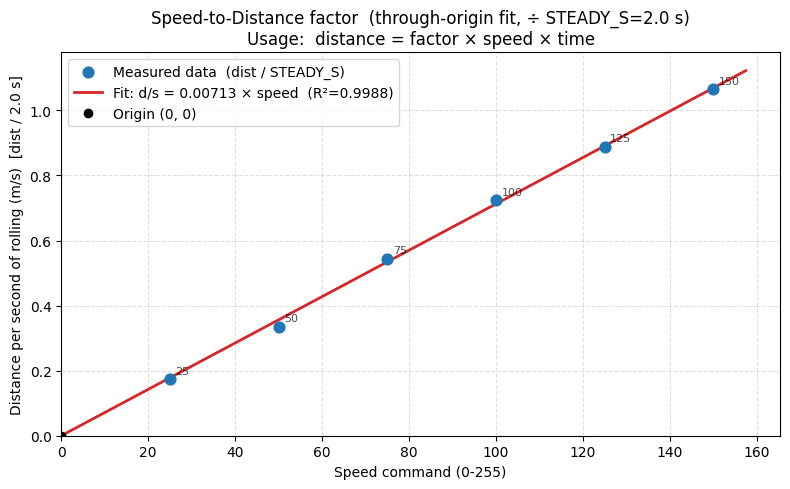

In [5]:
factor = plot_speed_distance_factor(runs_metrics, out_path=str(DATA_OUTPUT / "speed_distance_factor.png"))

## Speed Analysis — Single Run

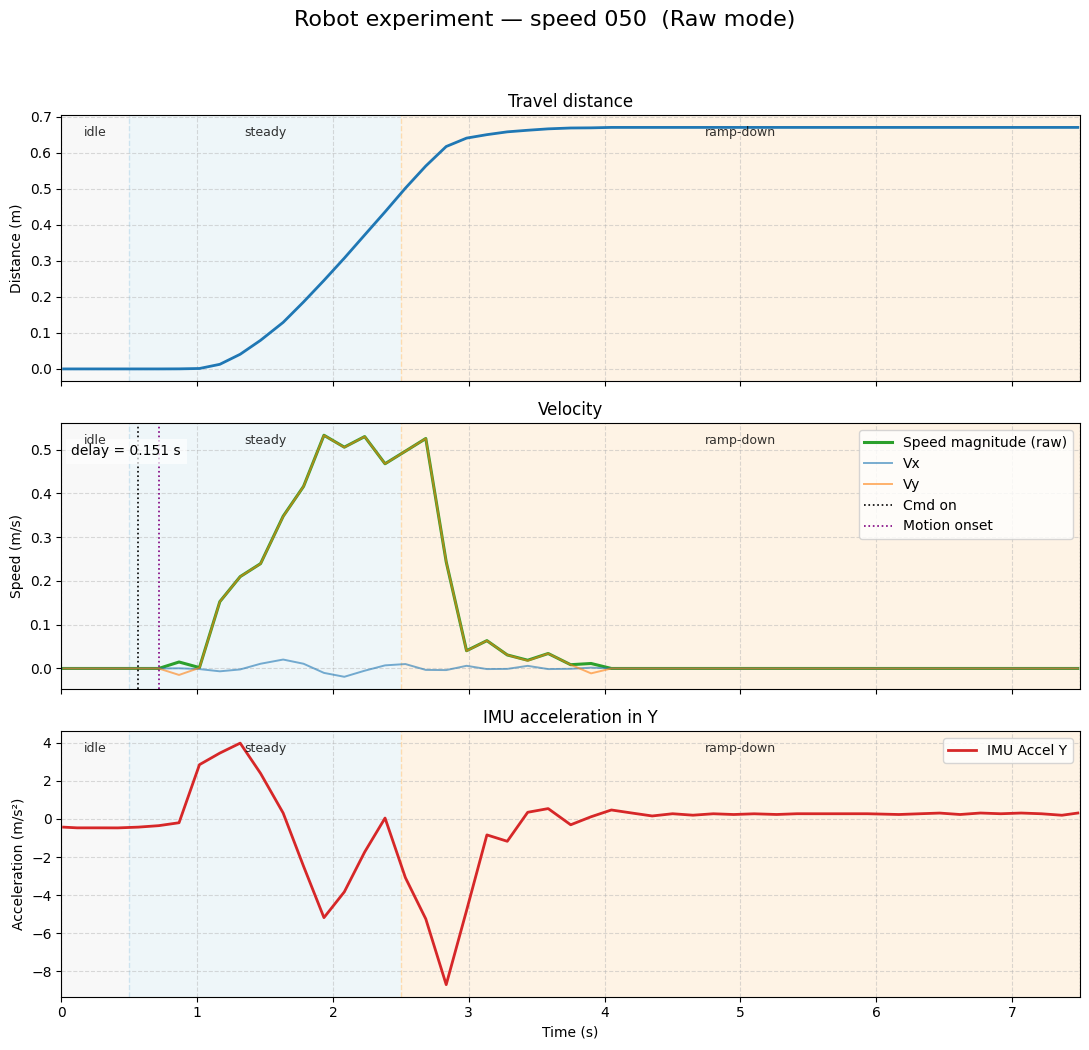

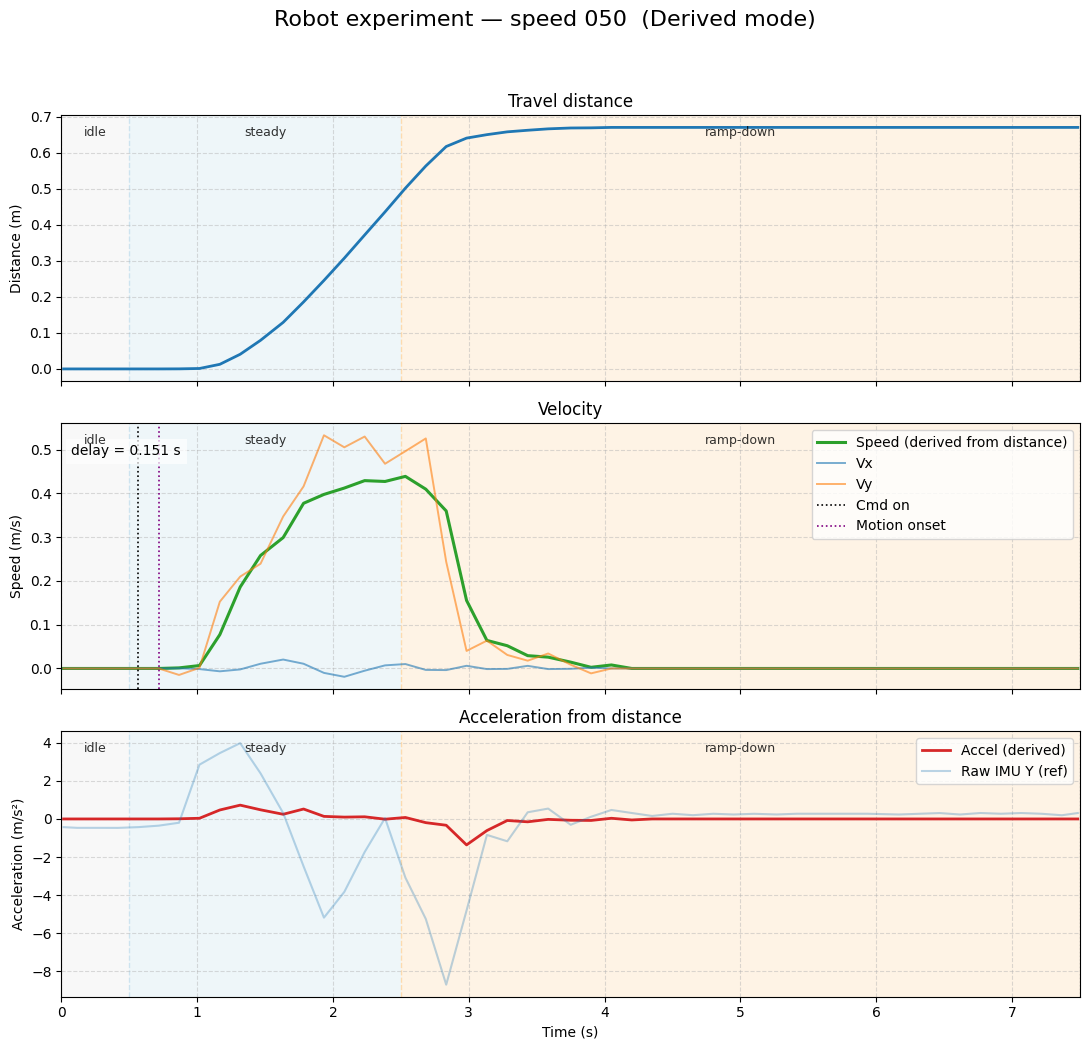

In [6]:
plot_single_speed(SELECTED_SPEED, runs_df, mode='raw',     show_components=True)
plot_single_speed(SELECTED_SPEED, runs_df, mode='derived', show_components=True)

## Speed Analysis — All Speeds

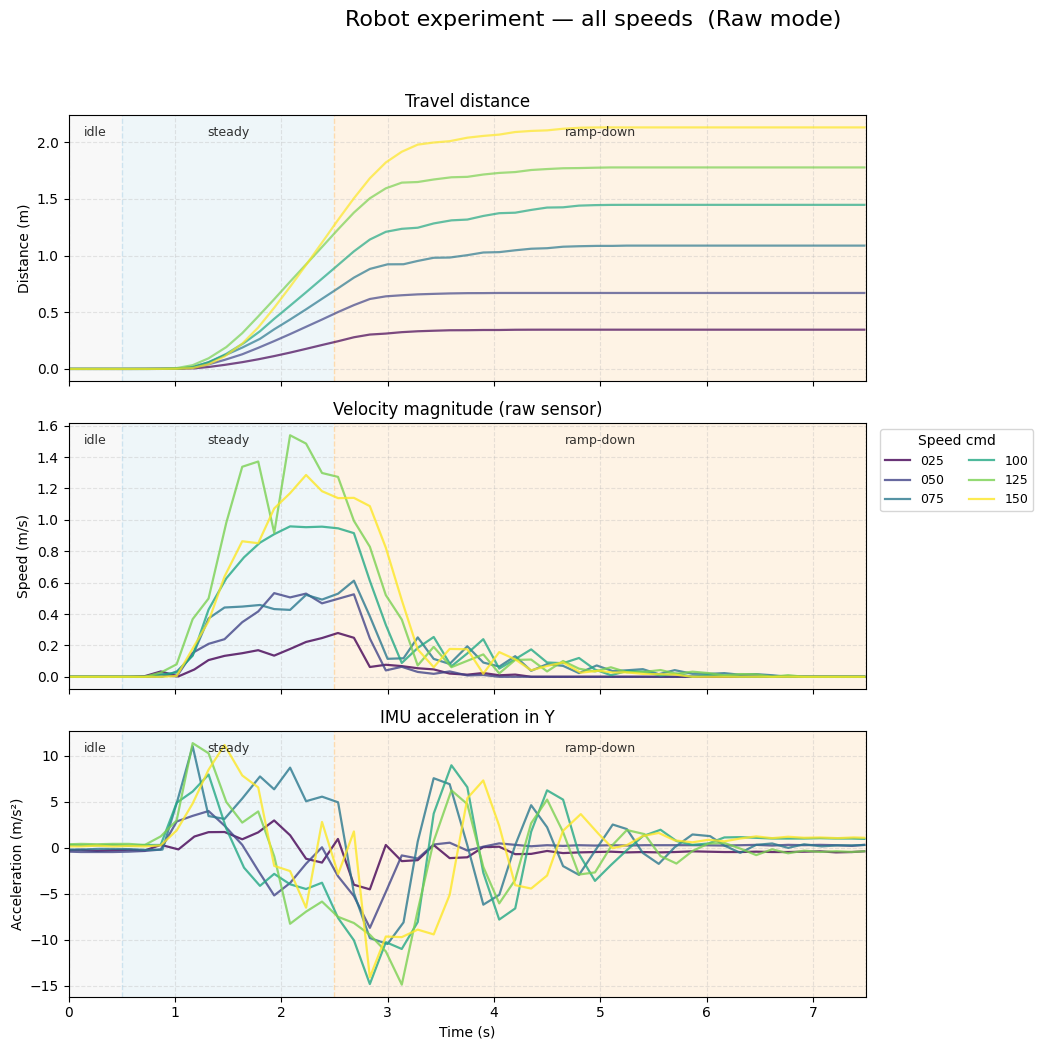

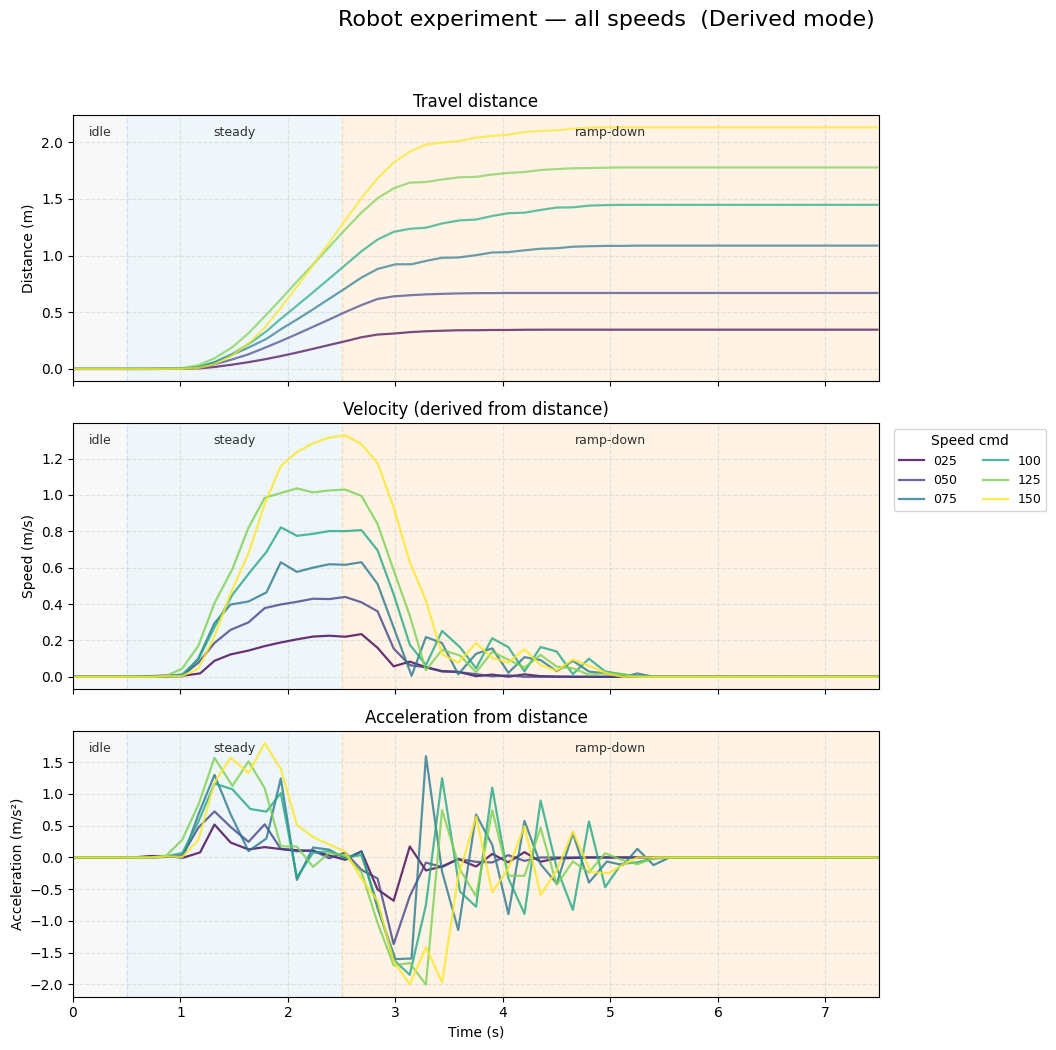

In [7]:
plot_all_speeds(runs_df, mode='raw')
plot_all_speeds(runs_df, mode='derived')

## Calibration — Grid Search

In [8]:
max_speed_range, max_accel_range = build_ranges(
    SPEED_MIN, SPEED_MAX, SPEED_STEPS,
    ACCEL_MIN, ACCEL_MAX, ACCEL_STEPS,
)
print(f"Max Speed Range: {max_speed_range[0]} - {max_speed_range[-1]}  | Steps: {max_speed_range[1] - max_speed_range[0]}")
print(f"Max Accel Range: {max_accel_range[0]} - {max_accel_range[-1]}  | Steps: {max_accel_range[1] - max_accel_range[0]}")
# max_accel_range, max_speed_range

Max Speed Range: 0.0 - 4.0  | Steps: 0.025
Max Accel Range: 0.0 - 4.0  | Steps: 0.025


In [9]:
best_speed, best_accel, rmse_grid = grid_search(runs_metrics, max_speed_range, max_accel_range, use_percent_error=USE_PERCENT_ERROR, cache_path=GRID_CACHE)

save_best_params(
    OUT_PARAMS,
    best_speed, best_accel,
    best_rmse=float(rmse_grid.min()),
    grid_config={
        'speed_range': [SPEED_MIN, SPEED_MAX, SPEED_STEPS],
        'accel_range': [ACCEL_MIN, ACCEL_MAX, ACCEL_STEPS],
    },
    use_percent_error=USE_PERCENT_ERROR,
)

print(f'\nPlug into SpheroController(')
print(f'    max_speed_ms  = {best_speed:.4f},')
print(f'    max_accel_ms2 = {best_accel:.4f},')
print(f')')
print_metrics_table_with_sim(runs_metrics, best_speed, best_accel)

⚡ Cache loaded from 'output\grid_cache.npz'
   speed : 0.000 → 4.000  (161 steps)
   accel : 0.000 → 4.000  (161 steps)
   best  : max_speed=1.8000 m/s  max_accel=0.5500 m/s²
   ⚠  Delete the file to force a fresh search.
Best params saved → output\best_params.json

Plug into SpheroController(
    max_speed_ms  = 1.8000,
    max_accel_ms2 = 0.5500,
)

REAL vs SIM METRICS  (max_speed=1.8000 m/s, max_accel=0.5500 m/s²)
  Cmd | Real (m) |  Sim (m) |   Gap % |   MaxSpd |   MaxAcc |   MaxDec | Dur (s)
--------------------------------------------------------------------------------
   25 |    0.346 |    0.352 |    -1.7% |    0.279 |    0.376 |   -0.723 |   2.717
   50 |    0.670 |    0.705 |    -5.2% |    0.533 |    0.693 |   -1.615 |   2.267
   75 |    1.088 |    1.058 |    +2.7% |    0.612 |    1.127 |   -1.568 |   3.945
  100 |    1.448 |    1.411 |    +2.5% |    0.958 |    1.592 |   -1.947 |   3.933
  125 |    1.778 |    1.764 |    +0.8% |    1.539 |    2.622 |   -1.577 |   2.566
  150 |

## Calibration Results

Plot saved → output\calibration_results.png


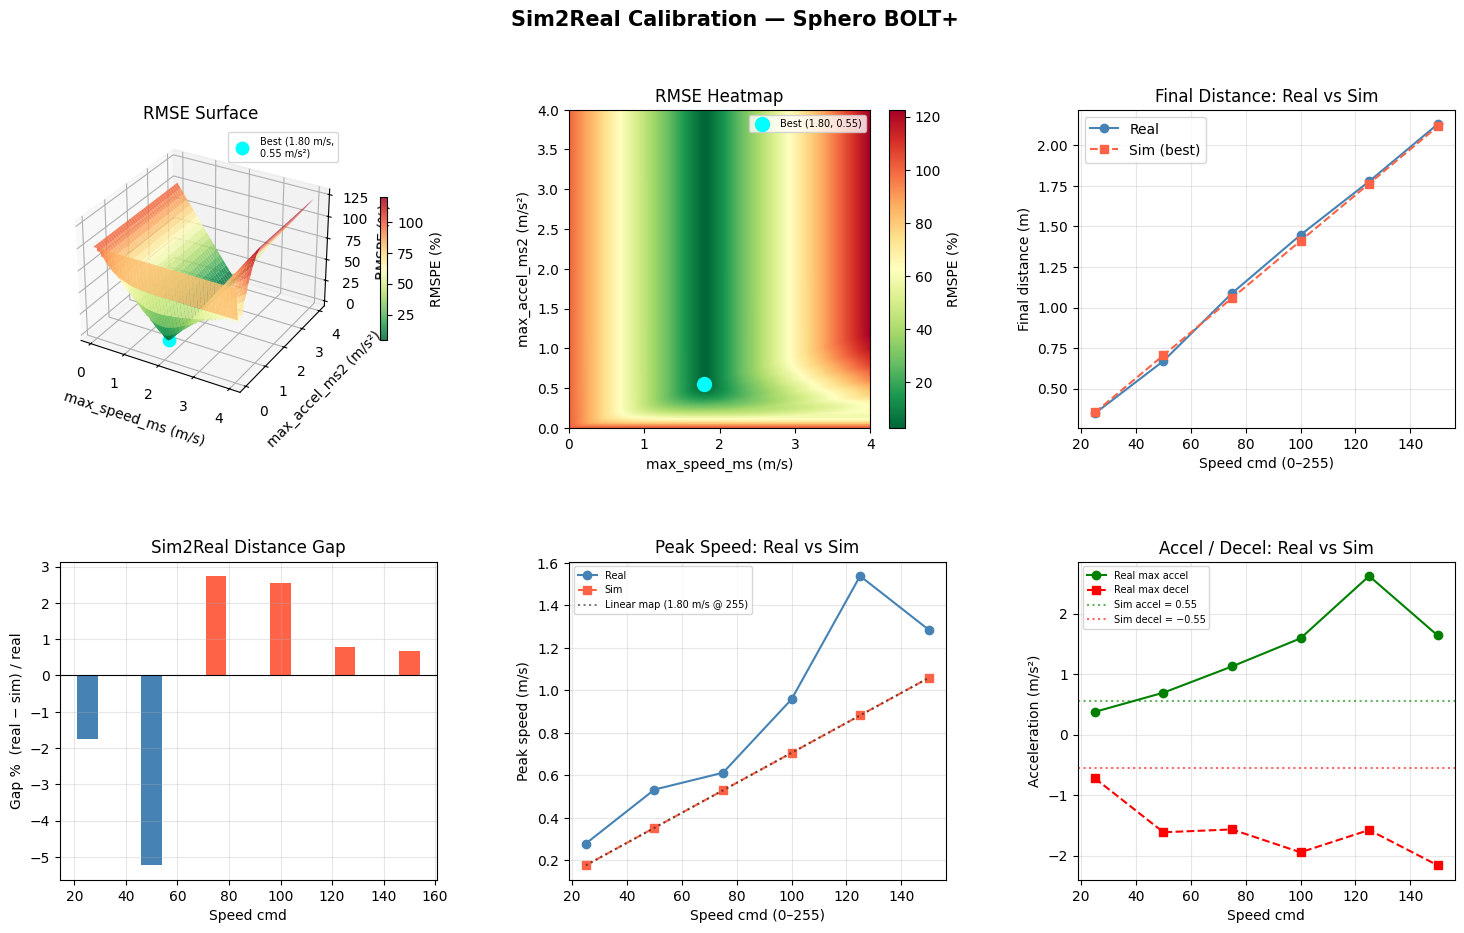

In [10]:
plot_results(
    runs_metrics,
    best_speed,
    best_accel,
    rmse_grid,
    max_speed_range,
    max_accel_range,
    out_path=OUT_FIGURE,
    rmse_unit=RMSE_UNIT,
)

## Sim vs Real

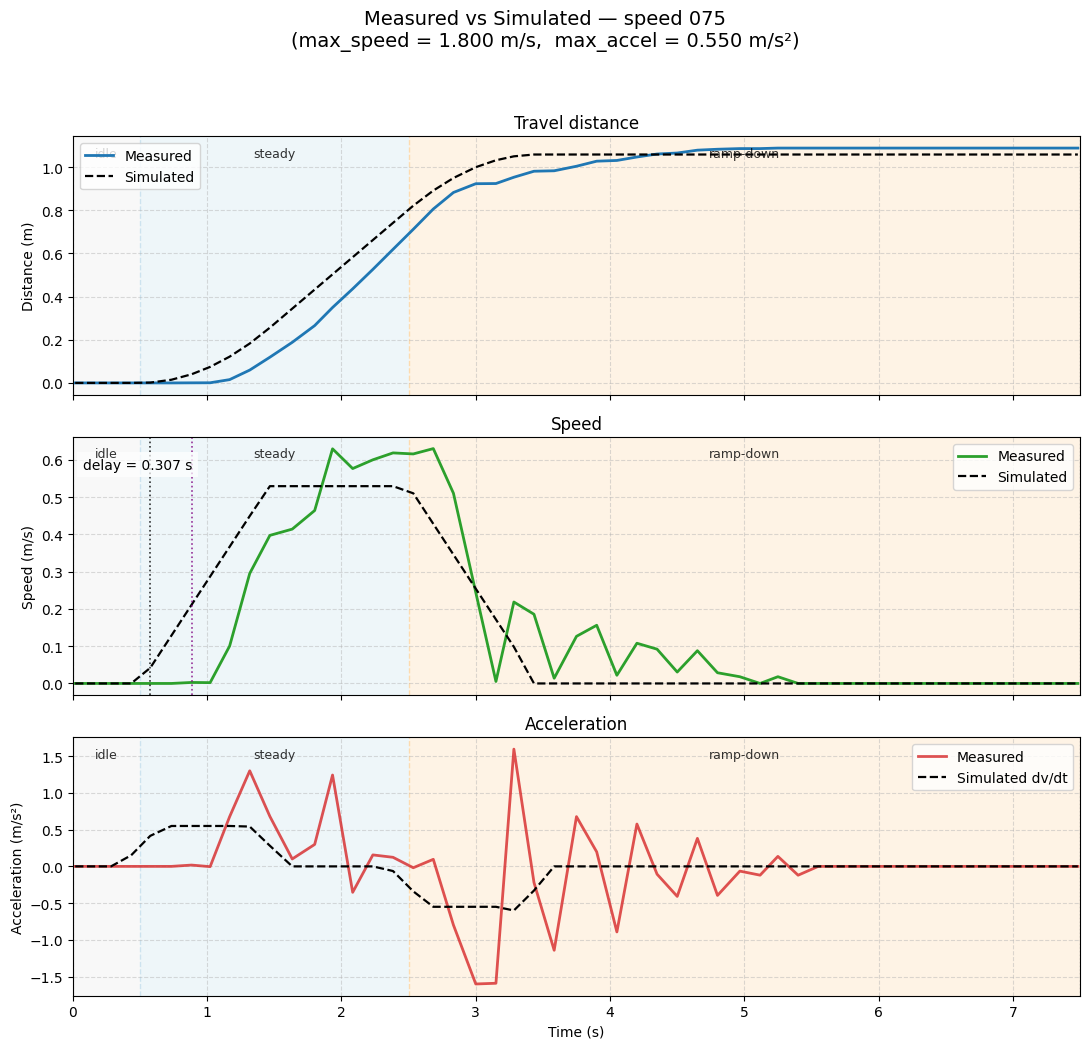

In [11]:
SELECTED_SPEED = 75
plot_single_speed_with_sim(SELECTED_SPEED, runs_df, best_speed, best_accel)

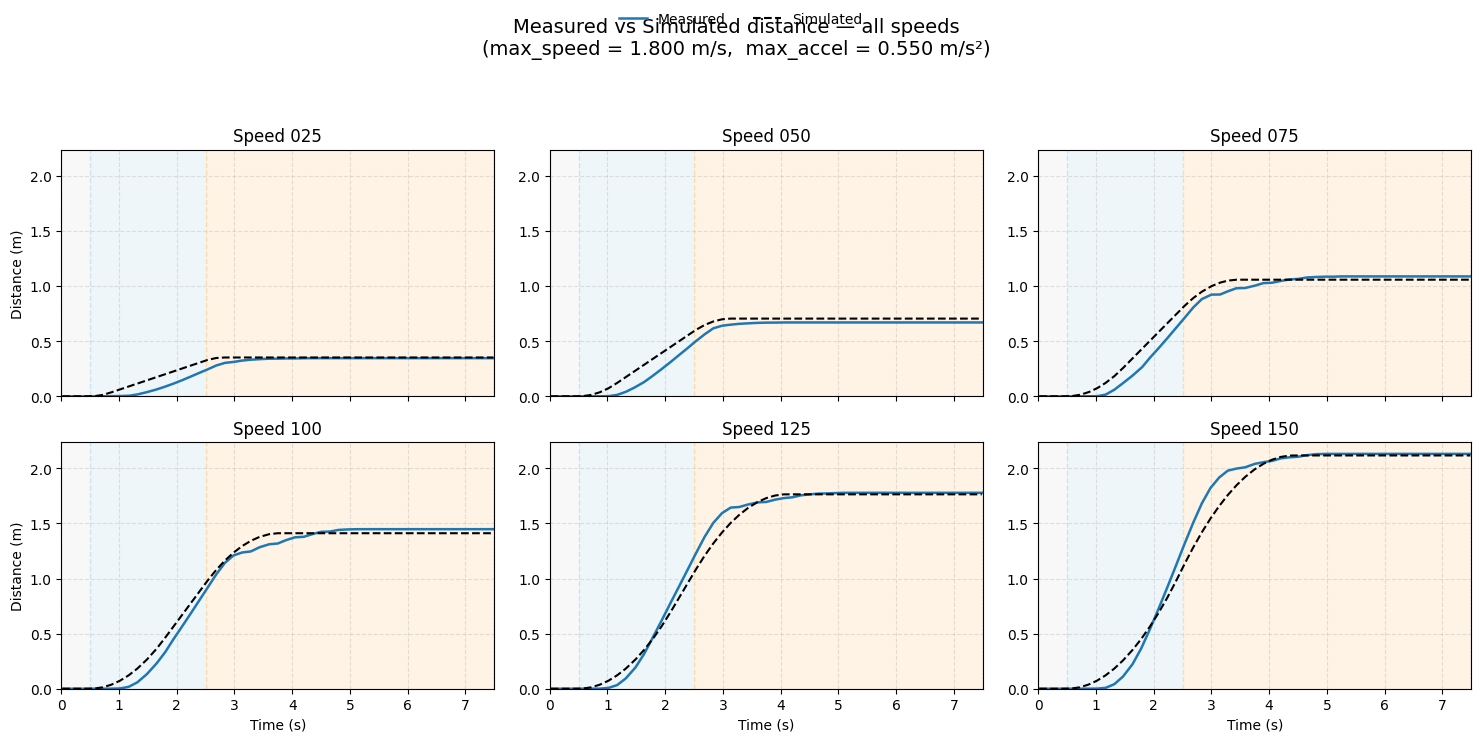

In [12]:
plot_all_distance_with_sim_subplots(runs_df, best_speed, best_accel, cols=3, share_y=False)
#plot_all_distance_with_sim_subplots(runs_df, 2, 4, cols=3)

## Motion Delay

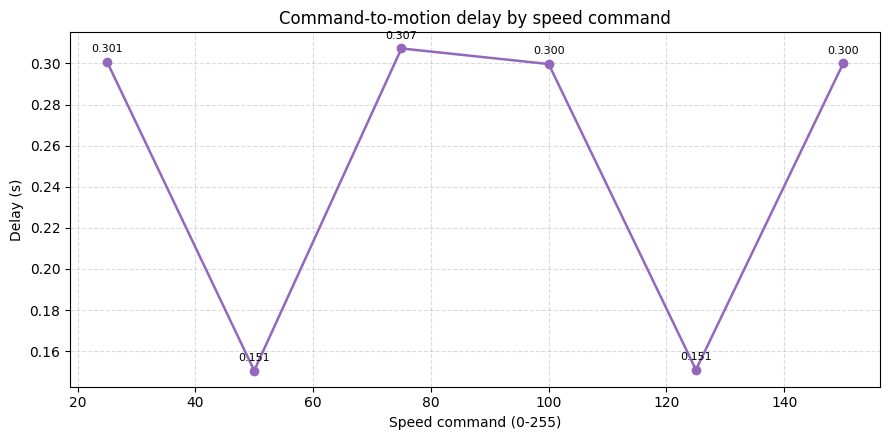

In [13]:
plot_delay_vs_speed(runs_df)

# Sapien

In [14]:
from utils.calib_sapien import grid_search_sapien
from utils.calib_search import build_ranges, save_best_params

In [15]:
speed_range, accel_range = build_ranges(
    SPEED_MIN_SAPIEN, SPEED_MAX_SAPIEN, SPEED_STEPS_SAPIEN,
    ACCEL_MIN_SAPIEN, ACCEL_MAX_SAPIEN, ACCEL_STEPS_SAPIEN,
)
print(f"speed_range: {speed_range[0]:.2f} → {speed_range[-1]:.2f}, step={speed_range[1]-speed_range[0]:.4f}, N={len(speed_range)}")
print(f"accel_range: {accel_range[0]:.2f} → {accel_range[-1]:.2f}, step={accel_range[1]-accel_range[0]:.4f}, N={len(accel_range)}")

speed_range: 0.00 → 4.00, step=0.0250, N=161
accel_range: 0.00 → 4.00, step=0.0250, N=161


In [16]:
from utils.calib_sapien import make_simulate_fn

sim_fn = make_simulate_fn()
best_speed, best_accel, rmse_grid = grid_search_sapien(
    runs_metrics,                # same runs list from your existing section
    speed_range,
    accel_range,
    use_percent_error=USE_PERCENT_ERROR,
    cache_path=GRID_CACHE_SAPIEN
)
# Uses SAPIEN engine for sim column
print_metrics_table_with_sim(runs_metrics, best_speed, best_accel, simulate_fn=sim_fn)

⚡ Cache loaded from 'output\grid_cache_sapien.npz'
   speed : 0.000 → 4.000  (161 steps)
   accel : 0.000 → 4.000  (161 steps)
   best  : max_speed=1.8250 m/s  max_accel=0.5750 m/s²
   ⚠  Delete the file to force a fresh search.

REAL vs SIM METRICS  (max_speed=1.8250 m/s, max_accel=0.5750 m/s²)
  Cmd | Real (m) |  Sim (m) |   Gap % |   MaxSpd |   MaxAcc |   MaxDec | Dur (s)
--------------------------------------------------------------------------------
   25 |    0.346 |    0.343 |    +0.9% |    0.279 |    0.376 |   -0.723 |   2.717
   50 |    0.670 |    0.700 |    -4.4% |    0.533 |    0.693 |   -1.615 |   2.267
   75 |    1.088 |    1.056 |    +2.9% |    0.612 |    1.127 |   -1.568 |   3.945
  100 |    1.448 |    1.413 |    +2.4% |    0.958 |    1.592 |   -1.947 |   3.933
  125 |    1.778 |    1.770 |    +0.5% |    1.539 |    2.622 |   -1.577 |   2.566
  150 |    2.131 |    2.126 |    +0.2% |    1.286 |    1.639 |   -2.161 |   2.883


In [17]:
import numpy as np
save_best_params(
    path=str(DATA_OUTPUT / "best_params_sapien.json"),
    best_speed=best_speed,
    best_accel=best_accel,
    best_rmse=float(np.min(rmse_grid)),
    grid_config={
        'speed_range': [SPEED_MIN_SAPIEN, SPEED_MAX_SAPIEN, SPEED_STEPS_SAPIEN],
        'accel_range': [ACCEL_MIN_SAPIEN, ACCEL_MAX_SAPIEN, ACCEL_STEPS_SAPIEN],
    },
)

Best params saved → output\best_params_sapien.json


Plot saved → output\calibration_results_sapien.png


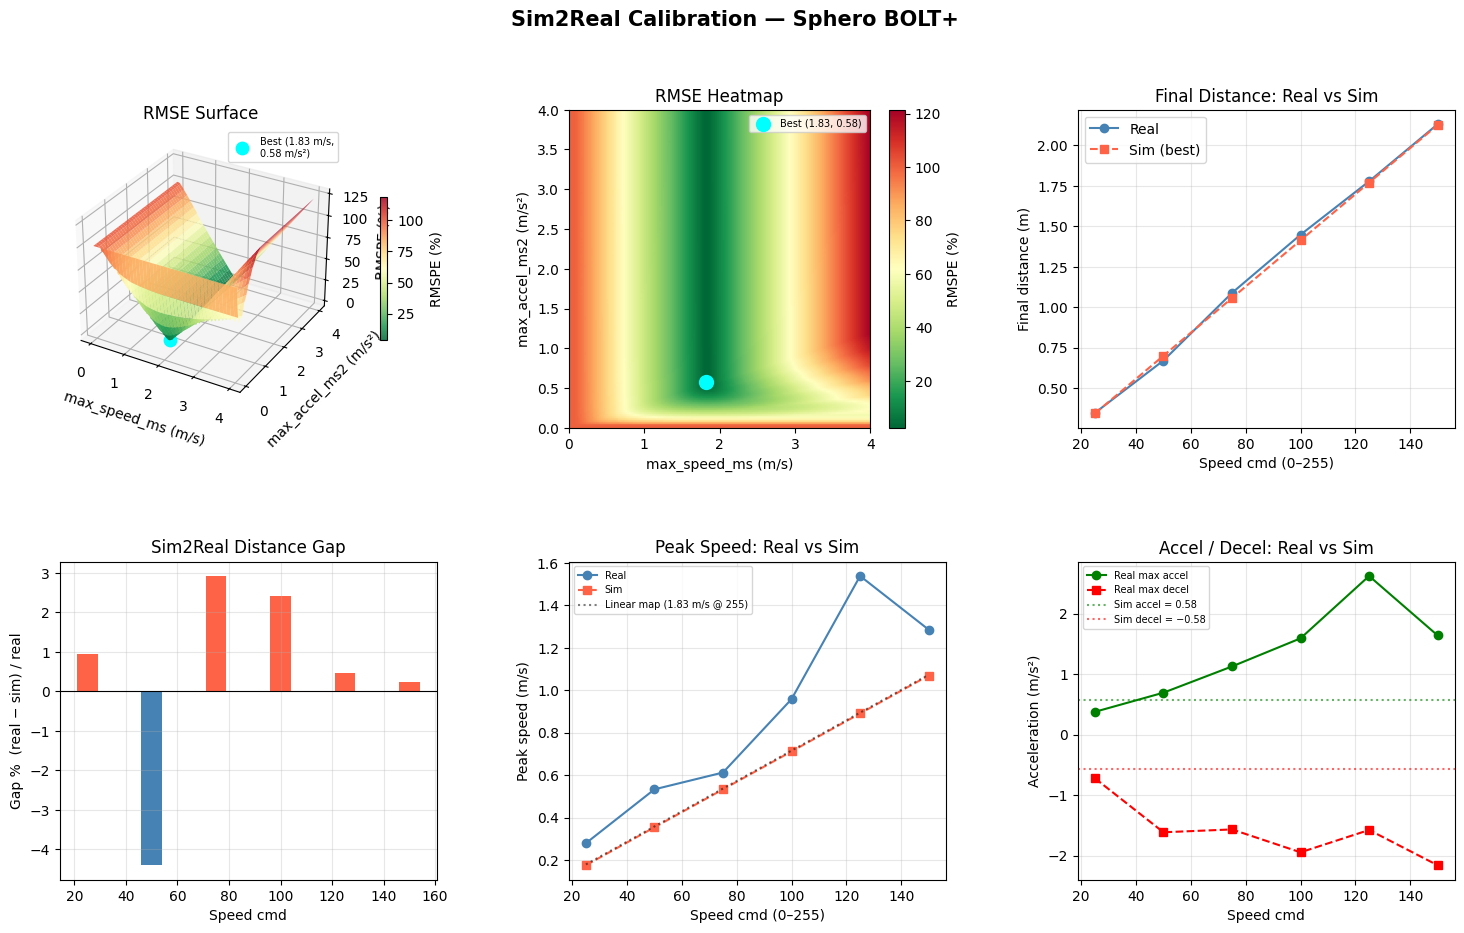

In [18]:
# ── Sapien: same plots as above but using SAPIEN physics ─────────────────────


plot_results(
    runs_metrics,
    best_speed, best_accel,
    rmse_grid,
    speed_range, accel_range,
    out_path=str(DATA_OUTPUT / "calibration_results_sapien.png"),
    rmse_unit=RMSE_UNIT,
    simulate_fn=sim_fn,
)

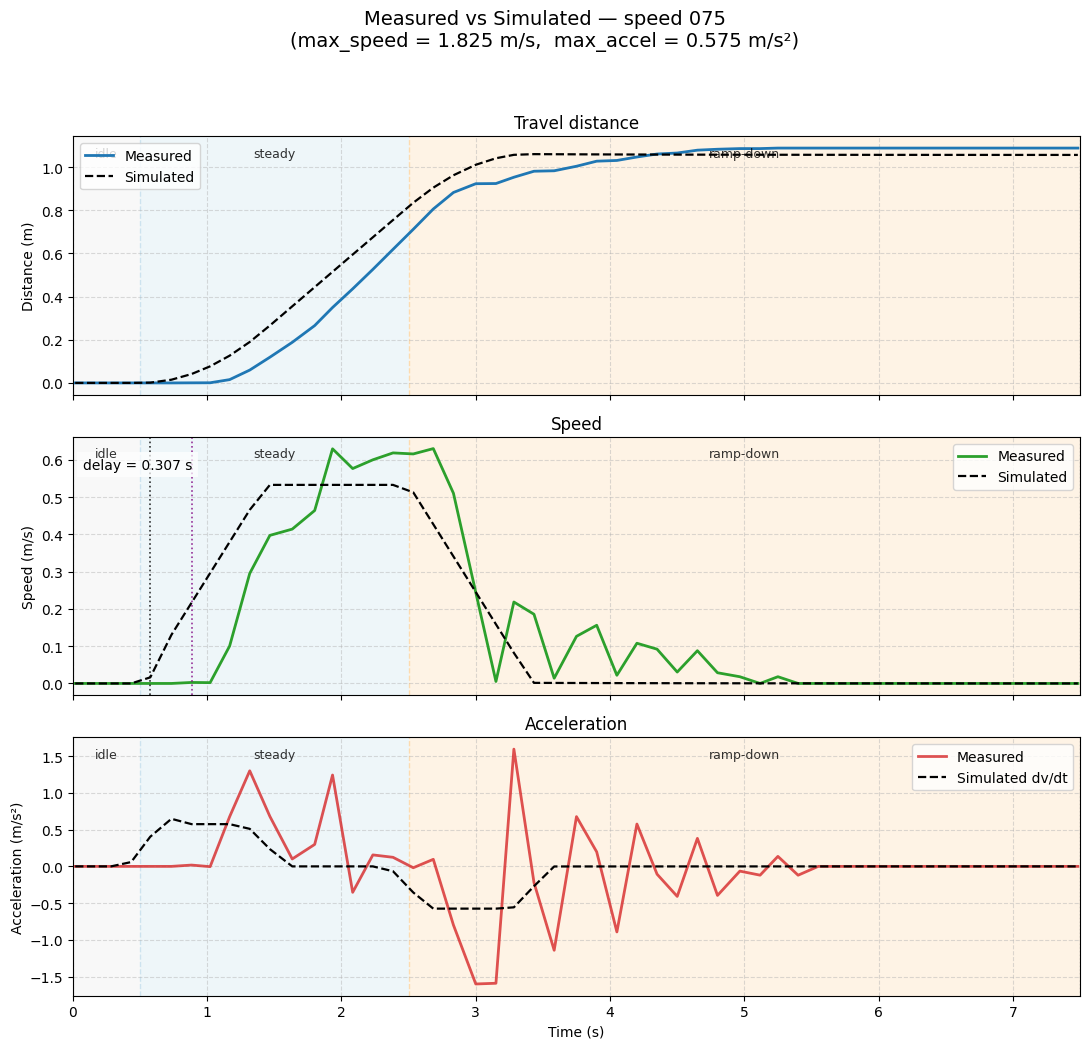

In [19]:
SELECTED_SPEED = 75
plot_single_speed_with_sim(SELECTED_SPEED, runs_df, best_speed, best_accel, simulate_fn=sim_fn)

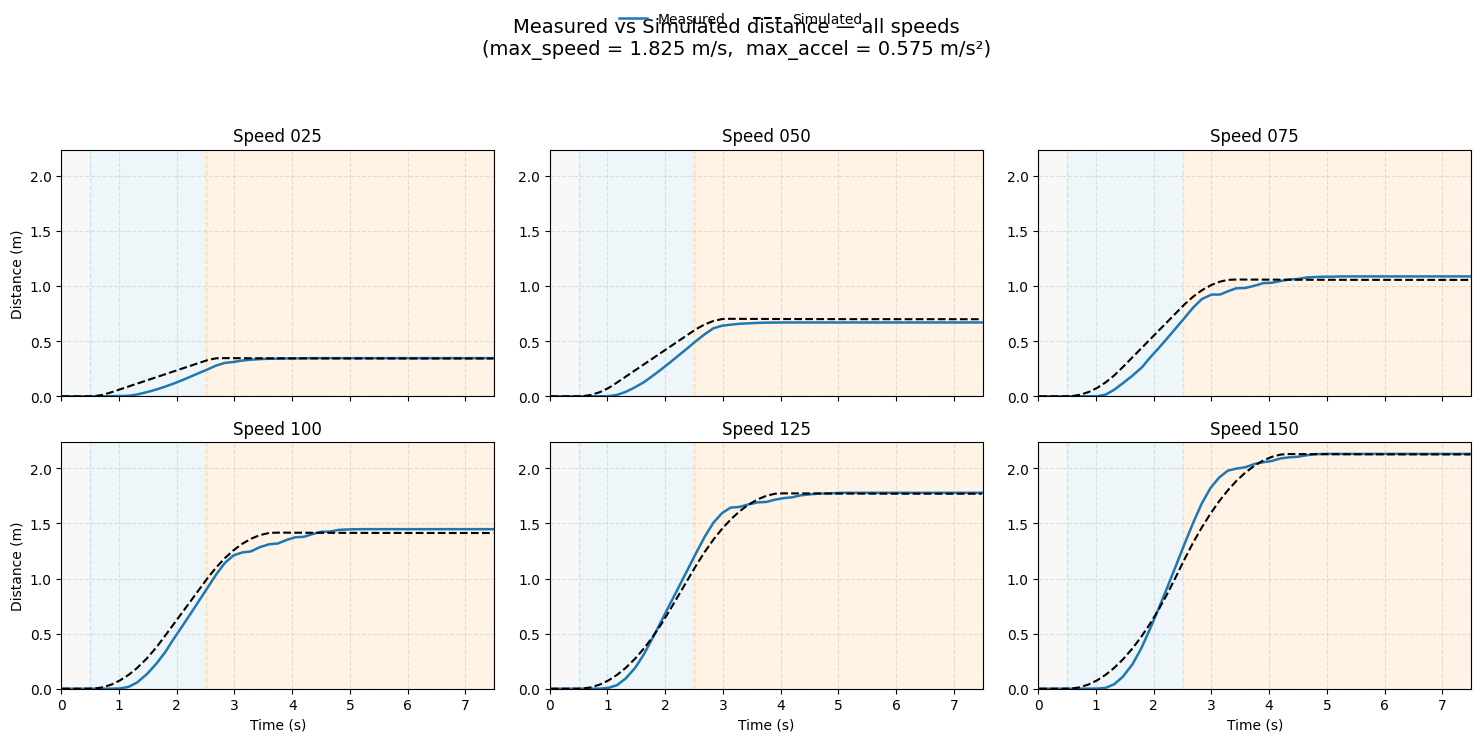

In [20]:
plot_all_distance_with_sim_subplots(runs_df, best_speed, best_accel, cols=3, share_y=False, simulate_fn=sim_fn)

In [21]:
# Close engine when done
#sim_fn.engine.close()

Panel 'rmse_heatmap' saved → output\sapien_rmse_heatmap.png


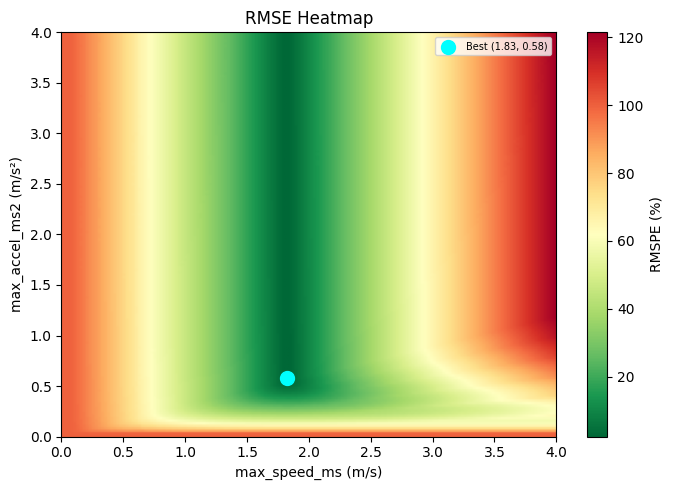

Panel 'distance' saved → output\sapien_distance.png


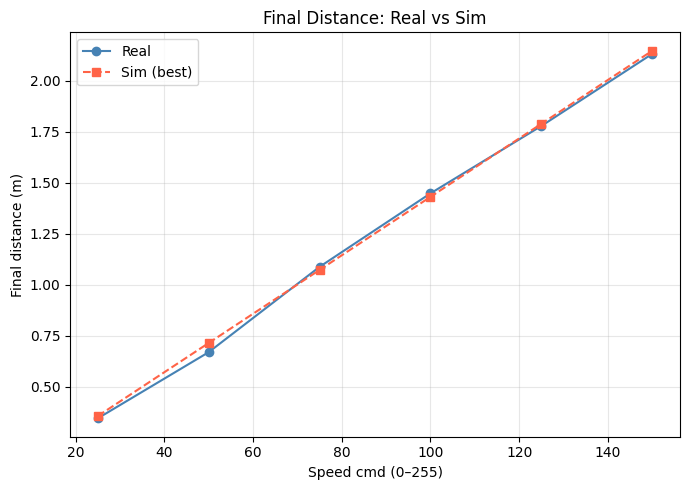

Panel 'accel_decel' saved → output\sapien_accel_decel.png


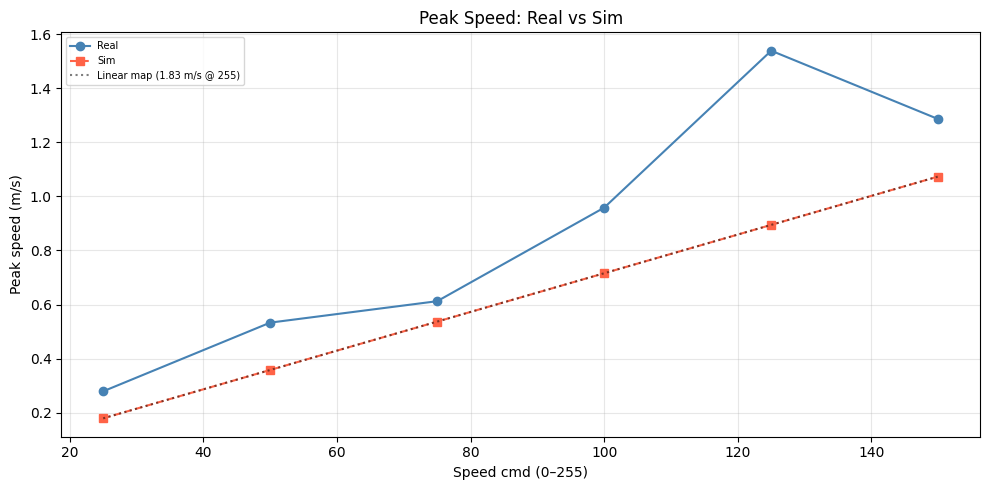

Panel 'gap' saved → output\sapien_gapl.png


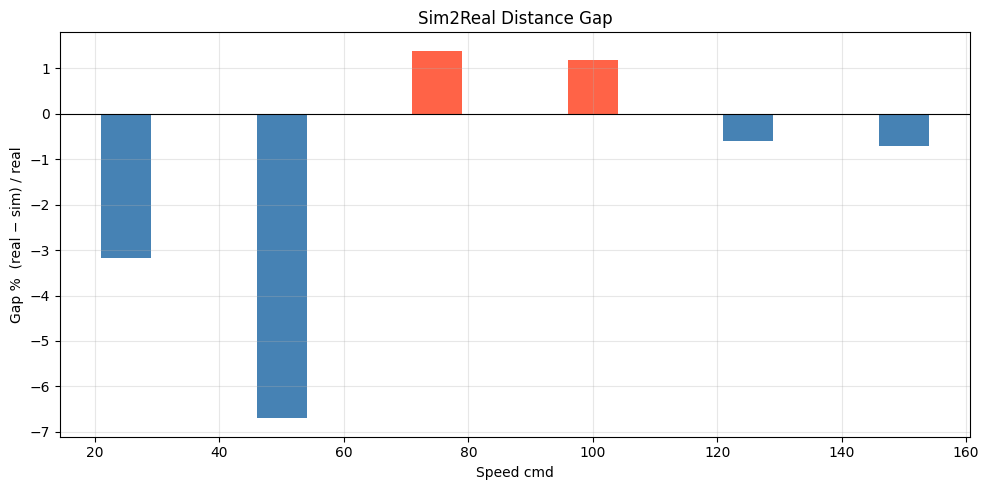

In [22]:
# ── Export individual panels for thesis ───────────────────────────────────────
plot_panel("rmse_heatmap", runs_metrics, best_speed, best_accel,
           rmse_grid=rmse_grid, max_speed_range=max_speed_range,
           max_accel_range=max_accel_range,
           rmse_unit=RMSE_UNIT, out_path=str(DATA_OUTPUT / "sapien_rmse_heatmap.png"), figsize=(7, 5))

plot_panel("distance", runs_metrics, best_speed, best_accel,
           out_path=str(DATA_OUTPUT / "sapien_distance.png"))

plot_panel("accel_decel", runs_metrics, best_speed, best_accel,
           out_path=str(DATA_OUTPUT / "sapien_accel_decel.png"), figsize=(10, 5))

plot_panel("gap", runs_metrics, best_speed, best_accel,
           out_path=str(DATA_OUTPUT / "sapien_gapl.png"), figsize=(10, 5))